In [1]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

In [2]:
from pyha_analyzer import extractors

2025-08-01 15:37:20.415127: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754087840.453622 1239077 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754087840.458870 1239077 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754087840.482806 1239077 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754087840.482825 1239077 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754087840.482827 1239077 computation_placer.cc:177] computation placer alr

In [3]:
coralreef_extractor = extractors.GNNCoralReef()
coral_ads = coralreef_extractor("/home/s.kamboj.400/pyha-analyzer-2.0/csv_for_gnn/Coral/surfperch_results.csv")
coral_ads

sampling 923 from (Paola, 0)
sampling 923 from (Paola, 1)
Loaded: 1846 samples


Casting the dataset:   0%|          | 0/1292 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/166 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/388 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sample_rate', 'labels', 'filepath', 'audio', 'audio_in', 'season', 'timeOfDay', 'sounds'],
        num_rows: 1292
    })
    valid: Dataset({
        features: ['sample_rate', 'labels', 'filepath', 'audio', 'audio_in', 'season', 'timeOfDay', 'sounds'],
        num_rows: 166
    })
    test: Dataset({
        features: ['sample_rate', 'labels', 'filepath', 'audio', 'audio_in', 'season', 'timeOfDay', 'sounds'],
        num_rows: 388
    })
})

In [4]:
from pyha_analyzer.preprocessors import MelSpectrogramPreprocessors

# TODO: allow for normalization system

# preprocessor acts as a function for processing
# class allows us to configure parameters and whatnot
preprocessor = MelSpectrogramPreprocessors(duration=5, class_list=coral_ads["train"].features["labels"].feature.names)

coral_ads["train"].set_transform(preprocessor)
coral_ads["valid"].set_transform(preprocessor)
coral_ads["test"].set_transform(preprocessor)
coral_ads["train"][[0, 1]]["audio"][0].mean()

0.04410471

In [5]:
coral_ads["valid"][23]

{'sample_rate': 48000,
 'labels': array([1., 0.], dtype=float32),
 'filepath': '/home/s.kamboj.400/unzipped-coral/Paola/Degraded_Reef/Pavonas_June2025/20250622_083219.WAV',
 'audio': array([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32),
 'audio_in': array([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32),
 'season': 'Rainy',
 'timeOfDay': 'Morning',
 'sounds': ['bioph_cascading_saw']}

In [6]:
#load model to generate vector embeddings for paola's audio
from pyha_analyzer.models import EfficentNet
import torch

model = EfficentNet(num_classes=2)
model.load_state_dict(torch.load("/home/s.kamboj.400/pyha-analyzer-2.0/saved-models/balanced_williams_paola_coral_model_524a67b.pt"))
model.eval()

EfficentNet(
  (model): EfficientNetForImageClassification(
    (efficientnet): EfficientNetModel(
      (embeddings): EfficientNetEmbeddings(
        (padding): ZeroPad2d((0, 1, 0, 1))
        (convolution): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=valid, bias=False)
        (batchnorm): BatchNorm2d(32, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
        (activation): SiLU()
      )
      (encoder): EfficientNetEncoder(
        (blocks): ModuleList(
          (0): EfficientNetBlock(
            (depthwise_conv): EfficientNetDepthwiseLayer(
              (depthwise_conv_pad): ZeroPad2d((0, 1, 0, 1))
              (depthwise_conv): EfficientNetDepthwiseConv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same, groups=32, bias=False)
              (depthwise_norm): BatchNorm2d(32, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
              (depthwise_act): SiLU()
            )
            (squeeze_excite): EfficientNetSqueezeEx

In [7]:
#helper function for generating surf perch embeddings for reefset audio
def extract_sounds(s):
    clean = s.strip("{}").replace("'", "")
    return [x.strip() for x in clean.split(",") if x.strip()]

In [ ]:
#NOTE TO DEVELOPER: This is code for generating avg pooled surf perch embeddings for the reefset audio. You can either do this for all possible reefset audios or for only the ones present in Paola's dataset
# I already saved the average pooled reefset embeddings in pooled_embeddings.csv (from all reefset audios present in Paula's dataset) to avoid having to re-run this. it is not the worst to re-run though (only took about 3 mins and did not crash kastner-ml)



# import os
# import pandas as pd
# import csv
# import librosa
# import numpy as np
# import random
# import tensorflow_hub as hub
# import tensorflow as tf
# import json

# model = hub.load('https://www.kaggle.com/models/google/surfperch/TensorFlow2/1/1')
# chunk_size = 5 * 32000  # 5 seconds at 32kHz
# #all_embeddings = []
# count=0

# # get all audio clips that are associated with reefset sounds
# # Path to CSV and audio directory

# audio_dir = "/home/s.kamboj.400/ReefSet_v1.0/full_dataset" 
# # #Use this to get all class labels. The code right now gets only the ones present in Paola's dataset from Anu's run, in order to avoid overloading the graph for testing purposes for now. Eventually, we will want to add all nodes for knowledge graph purposes
# # csv_path = "/home/s.kamboj.400/ReefSet_v1.0/reefset_labels_by_dataset.csv"
# # df = pd.read_csv(csv_path)
# # class_labels = df['Class label'].tolist()


# #IMPORTANT NOTE:renamed all 13 instances of geoph to geoph_waves in the surfperch results csv, since it seemed like geoph yielded no results
# # # Use this to get class labels only present in Paola's dataset
# csv_path= "/home/s.kamboj.400/pyha-analyzer-2.0/surfperch_results.csv" 
# df = pd.read_csv(csv_path)
# all_sounds = df['sounds'].apply(extract_sounds).explode() #explode flattens into single series so u can make it a set
# class_labels = set(all_sounds) #avoid duplicates

# # dicitonary where key is reefset noise and value is the avg pooled embedding of all audio files representing that noise
# label_to_files = {label: [] for label in class_labels}

# # Loop over all files in the reefset directory to average pool embeddings
# for fname in os.listdir(audio_dir):
#     if not fname.endswith(".wav"):
#         continue
#     # get the last word before .wav
#     try:
#         final_token = fname.rsplit(".", maxsplit=2)[-2]
#     except Exception as e:
#         print(f"Error at {e}")
#         continue  

#     # Add to dictionary if the final token is a known label
#     if final_token in label_to_files:
#         #label_to_files[final_token].append(os.path.join(audio_dir, fname))
#         audio_path=str(os.path.join(audio_dir, fname))
#         try:
#             # load and resample to 32kHz according to specifications
#             waveform, sr = librosa.load(audio_path, sr=32000)
#             waveform = waveform.astype(np.float32)
#             total_samples = len(waveform)

#             # check if clip atleast 5 seconds
#             if total_samples < chunk_size:
#                 #repeat it if it is not 5 seconds
#                 num_repeats = int(np.ceil(chunk_size / total_samples))
#                 waveform = np.tile(waveform, num_repeats)
#                 waveform = waveform[:chunk_size]
#                 start = 0
#             else:
#                 # if it is atelast 5 seconds, find random 5 second window to sample from
#                 start = random.randint(0, total_samples - chunk_size)

#             # extract one random 5s chunk
#             chunk = waveform[start:start + chunk_size]
#             chunk = np.expand_dims(chunk, axis=0)  # shape: (1, 160000)

#             # get embedding
#             outputs = model.infer_tf(tf.convert_to_tensor(chunk))
#             embedding = outputs["embedding"].numpy()[0]  # shape: (1280,)

#             #store to average later
#             label_to_files[final_token].append(embedding)


#         except Exception as e:
#             print(f"Error processing {audio_path}: {e}")
        

# for label, files in label_to_files.items():
#     #print(f"{label}: {len(files)} files")
#     all_embeddings_array = np.stack(files)          # shape: (num_files, 1280)
#     #resave the value as the pooled embedding rather than the stacked embedding
#     label_to_files[label] = np.mean(all_embeddings_array, axis=0) # shape: (1280,)
# #   print("Final pooled embedding shape:", label_to_files[label].shape)


# #SAVE TO FILE
# # Convert the dictionary to a list of rows
# rows = []
# for label, pooled_embedding_array in label_to_files.items():
#     embedding_list = pooled_embedding_array.tolist()
#     rows.append({
#         "class_label": label,
#         "embedding": json.dumps(embedding_list)
#     })
# # create DataFrame and save
# df_out = pd.DataFrame(rows)
# df_out.to_csv("pooled_embeddings.csv", index=False, quoting=csv.QUOTE_ALL)
# print("Saved to pooled_embeddings.csv")

2025-07-31 17:06:03.150764: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator jax2tf_infer_fn_/assert_equal_1/Assert/AssertGuard/Assert


Final pooled embedding shape: (1280,)
Final pooled embedding shape: (1280,)
Final pooled embedding shape: (1280,)
Final pooled embedding shape: (1280,)
Final pooled embedding shape: (1280,)
Final pooled embedding shape: (1280,)
Final pooled embedding shape: (1280,)
Final pooled embedding shape: (1280,)
Final pooled embedding shape: (1280,)
Final pooled embedding shape: (1280,)
Final pooled embedding shape: (1280,)
Final pooled embedding shape: (1280,)
Final pooled embedding shape: (1280,)
Final pooled embedding shape: (1280,)
Final pooled embedding shape: (1280,)
Final pooled embedding shape: (1280,)
Final pooled embedding shape: (1280,)
Final pooled embedding shape: (1280,)
Saved to pooled_embeddings.csv


In [8]:
from torch_geometric.data import HeteroData
data=HeteroData()

In [ ]:
# #get embedding for Paola audio from trained efficientnet model
# batch_size = 32

# for split in ["train", "valid"]:
#     dataset = coral_ads[split]
#     for i in range(0, len(dataset), batch_size):
#         batch_items = dataset.select(range(i, min(i + batch_size, len(dataset))))

#         # build input tensor
#         batch_inputs = torch.stack([
#             torch.tensor(item["audio_in"], dtype=torch.float32)
#             for item in batch_items
#         ])

#         # get embeddings through batching
#         embeddings = model.get_embedding(batch_inputs)
        

#         # # Loop through items and create metadata
#         # for j, (embedding, item) in enumerate(zip(embeddings, batch_items)):
#         #     label_vec = item["labels"]
#         #     if (label_vec == [0.0, 1.0]).all():
#         #         curr_label = "Non_Degraded_Reef"
#         #     elif (label_vec == [1.0, 0.0]).all():
#         #         curr_label = "Degraded_Reef"
#         #     else:
#         #         curr_label = "Unknown"
#         #         print("Unknown label:", label_vec)

#         #     metadata = {
#         #         "id": f"{split}{i + j}",
#         #         "vector_embedding": embedding.tolist(),
#         #         "label": curr_label,
#         #         "audio_path": item["filepath"]
#         #     }

#         #     table_rows.append(metadata)


In [9]:
import pandas as pd
import json

reef_df = pd.read_csv("/home/s.kamboj.400/pyha-analyzer-2.0/csv_for_gnn/Coral/pooled_surfperch_embeddings.csv")

# reef_embeddings = torch.tensor(
#     reef_df["embedding"].apply(json.loads).tolist(), dtype=torch.float
# )

# data['reefset_audio'].x = reef_embeddings

# print(data)


# Build the hashmap
reefset_map = {}
for _, row in reef_df.iterrows():
    label = row[0]  # class label 
    embedding = torch.tensor(json.loads(row[1]), dtype=torch.float)
    reefset_map[label] = embedding

# for key, value  in reefset_map.items():
#     print(f"{key}: {value}")

/tmp/ipykernel_1239077/2360514935.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = row[0]  # class label
/tmp/ipykernel_1239077/2360514935.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  embedding = torch.tensor(json.loads(row[1]), dtype=torch.float)


In [10]:
batch_size = 32

paola_audio_features = []
reefset_audio_features = []
season_vals, time_vals, degradation_vals = set(), set(), set()

season_edges, time_edges, degr_edges, reef_edges = [], [], [], []

sound_to_nodeid = {}  # map from sound name to reefset node index so you remember how to make edges later

season_list_raw = []
time_list_raw = []
degr_list_raw = []

dataset = coral_ads["train"]

for i in range(0, len(dataset), batch_size):
    batch_items = dataset.select(range(i, min(i + batch_size, len(dataset))))

    # Prepare batch input tensor
    batch_inputs = torch.stack([
        torch.tensor(item["audio_in"], dtype=torch.float32)
        for item in batch_items
    ])

    # Get batched embeddings
    with torch.no_grad():
        embeddings = model.get_embedding(batch_inputs)  # shape: (batch, 1280)
    
    for j, (embedding, item) in enumerate(zip(embeddings, batch_items)):
        idx = i + j  # global index

        # Add embedding
        paola_audio_features.append(embedding)

        # Extract metadata
        label_vec = item["labels"]
        degr = "Non_Degraded" if ((label_vec == [0.0, 1.0]).all()) else "Degraded"
        season = item["season"]
        time = item["timeOfDay"]

        # Collect for vocab building
        degradation_vals.add(degr)
        season_vals.add(season)
        time_vals.add(time)

        # Store raw for edge building
        degr_list_raw.append(degr)
        season_list_raw.append(season)
        time_list_raw.append(time)

        #deal with reefset sounds
        sounds = item.get("sounds", [])
        for sound in sounds:
            if sound not in reefset_map:
                continue  # skip unknown sounds

            # If this is the first time we see this sound, add as a new node
            if sound not in sound_to_nodeid:
                reefset_audio_features.append(reefset_map[sound])
                sound_to_nodeid[sound] = len(reefset_audio_features) - 1

            # Create edge from paola_audio[idx] to reefset_audio[node_id]
            reef_edges.append([idx, sound_to_nodeid[sound]])

In [11]:
data['paola_audio'].x = torch.stack(paola_audio_features)
data['reefset_audio'].x = torch.stack(reefset_audio_features)

In [12]:
season2id = {s: i for i, s in enumerate(sorted(season_vals))}
time2id = {t: i for i, t in enumerate(sorted(time_vals))}
degr2id = {d: i for i, d in enumerate(sorted(degradation_vals))}

data['season'].x = torch.eye(len(season2id))
data['time'].x = torch.eye(len(time2id))
data['degradation'].x = torch.eye(len(degr2id))

# Edge building
for idx in range(len(paola_audio_features)):
    data['paola_audio', 'has_season', 'season'].edge_index = torch.tensor([
        [idx for idx in range(len(season_list_raw))],
        [season2id[season_list_raw[idx]] for idx in range(len(season_list_raw))]
    ], dtype=torch.long)

    data['paola_audio', 'has_time', 'time'].edge_index = torch.tensor([
        [idx for idx in range(len(time_list_raw))],
        [time2id[time_list_raw[idx]] for idx in range(len(time_list_raw))]
    ], dtype=torch.long)

    data['paola_audio', 'has_degradation', 'degradation'].edge_index = torch.tensor([
        [idx for idx in range(len(degr_list_raw))],
        [degr2id[degr_list_raw[idx]] for idx in range(len(degr_list_raw))]
    ], dtype=torch.long)

if reef_edges:
    data['paola_audio', 'contains_sound', 'reefset_audio'].edge_index = torch.tensor(reef_edges).t().long()


# Assign node names so you can actually interpret output. does not affect training!!!
data['paola_audio'].node_names = [
    item['filepath'].split('/')[-1].replace('.WAV', '')
    for item in coral_ads["train"]
]
data['reefset_audio'].node_names = list(sound_to_nodeid.keys())
# Use sorted keys to match the one-hot vectors encoded earlier
data['season'].node_names = sorted(season_vals)         #['Dry', 'Rainy']
data['time'].node_names = sorted(time_vals)             # ['Afternoon', 'Morning', 'Night']
data['degradation'].node_names = sorted(degradation_vals)  # ['Degraded', 'Non_Degraded']



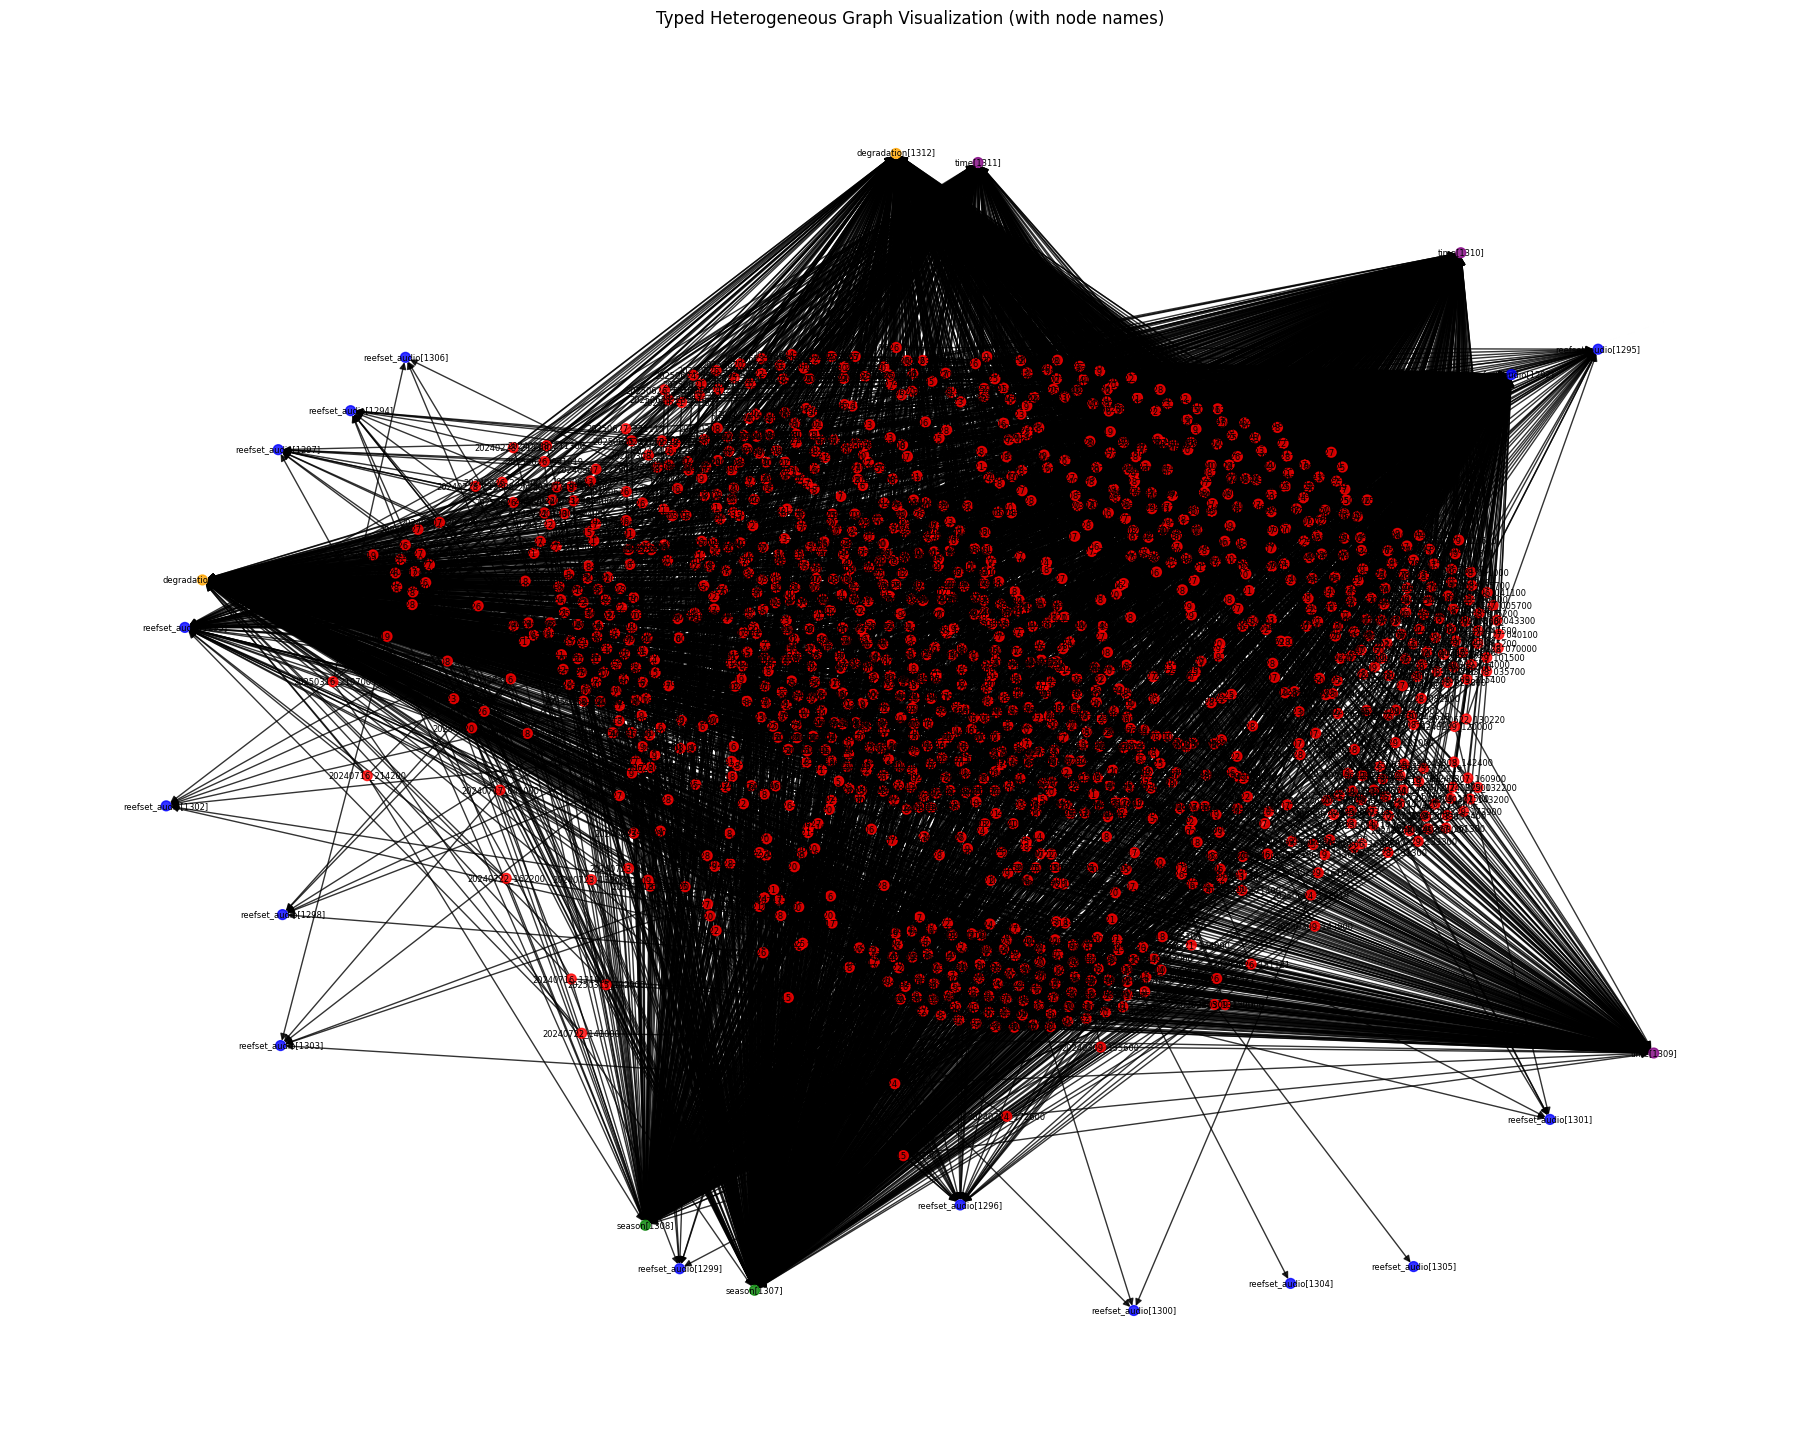

In [14]:
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt
import networkx as nx

# Step 1: Convert with node_names as attribute
G = to_networkx(data, node_attrs=["node_names"], edge_attrs=[])

# Step 2: Assign colors and labels
node_colors = []
labels = {}

for node in G.nodes():
    ntype = G.nodes[node]['type']
    node_id = node  # node is a tuple like ('paola_audio', 12)

    # Use node_names if available, otherwise fallback
    name_list = data[ntype].node_names if hasattr(data[ntype], 'node_names') else None
    label = name_list[node_id] if name_list and node_id < len(name_list) else f"{ntype}[{node_id}]"
    labels[node] = label

    # Color by node type
    if ntype == 'paola_audio':
        node_colors.append('red')
    elif ntype == 'reefset_audio':
        node_colors.append('blue')
    elif ntype == 'degradation':
        node_colors.append('orange')
    elif ntype == 'season':
        node_colors.append('green')
    elif ntype == 'time':
        node_colors.append('purple')
    else:
        node_colors.append('gray')

# Step 3: Draw with labels
plt.figure(figsize=(18, 14))
pos = nx.spring_layout(G, seed=42, k=0.3)  # k controls spacing
nx.draw(G, pos, node_color=node_colors, with_labels=False, node_size=50, alpha=0.8)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=6)
plt.title("Typed Heterogeneous Graph Visualization (with node names)")
plt.axis("off")
plt.show()


In [15]:
import torch.nn as nn

class FeatureEncoder(nn.Module):
    def __init__(self, data, embed_dim):
        super().__init__()
        self.embeddings = nn.ModuleDict()
        for node_type in data.node_types:
            if 'x' not in data[node_type] or data[node_type].x is None: # if the node type does not have 'x' feature aka does not have embedding yet then give it embedding. does not overwrite what does have an embedding
                num_nodes = data[node_type].num_nodes
                self.embeddings[node_type] = nn.Embedding(num_nodes, embed_dim) #random initialization

    def forward(self, x_dict):
        out = {}
        #x_dict["audio"] has an embedding vector already
        for node_type in data.node_types:
            if node_type in self.embeddings:
                out[node_type] = self.embeddings[node_type].weight
            elif node_type in x_dict:
                out[node_type] = x_dict[node_type]
            else:
                raise KeyError(f"Node type {node_type} not in x_dict or embeddings")
        
        return out
    

In [16]:
from torch_geometric.nn import HGTConv
import torch.nn.functional as F
from torch.nn import Linear, Module
import torch


##TODO : Activation function IE RELU!!!
class HGTEncoder(nn.Module):
    #hidden channels is the dimension of the embedidng vector as it keeps learning
    #num layers is essentially how many "hops" you can take. ie one layer means you cna only go to neighbor but 2 layers means you can go to neighbor's neighbor. dont make it too high then oversmoothing
    # num_heads = number of semantically important node types you want the model to distinguish between. too high of a number is computationally expensive
    def __init__(self, x_dict, metadata, hidden_channels=32, num_heads=4, num_layers=2):
        super().__init__()
        self.metadata = metadata # metadata contains info about all nodes and edges in the graph, as well as the features from previous function. this is built from the heterodata object
        #create dictionary of linear layers for each node type (it is dictionary because each node type cna have different dimension)
        self.input_lin = nn.ModuleDict()
        #store all layers and update features in a list 
        self.convs = nn.ModuleList()

        #get all different node types 
        for node_type in metadata[0]:
            if node_type not in x_dict:
                raise ValueError(f"{node_type} not in x_dict!")
            in_dim = x_dict[node_type].size(1)
            self.input_lin[node_type] = nn.Linear(in_dim, hidden_channels)


        for _ in range(num_layers):
            self.convs.append(HGTConv(
                in_channels=hidden_channels,
                out_channels=hidden_channels,
                metadata=metadata,
                heads=num_heads
            ))

    #x dict is result of feature encoder, which contains embeddings for all node types
    #edge_index_dict is a dictionary of edge indices for each edge type, which is used to define the connections between nodes in the graph
    def forward(self, x_dict, edge_index_dict):
        # print("x_dict before input_lin:")
        # for k, v in x_dict.items():
        #     print(f"{k}: shape = {v.shape}")
            
        #standardize all node features to the same dimension from self.input_lin[node_type] in the init function
        x_dict = {
            node_type: self.input_lin[node_type](x)
            for node_type, x in x_dict.items()
        }
        # print("x_dict after input_lin:")
        # for k, v in x_dict.items():
        #     print(f"{k}: shape = {v.shape}")
            
        #looks up neighbor that node has, applies attention to it & updates node features in x_dict itself
        for conv in self.convs:
            x_dict = conv(x_dict, edge_index_dict)
        
        
        #contians final rep of each node type after all layers. THIS is input for link predictor
        return x_dict
    


In [17]:
# class LinkPredictor(nn.Module):
#     def __init__(self, hidden_dim):
#         super().__init__()
#         #MLP that predicts whether 2 nodes should be connected. can learn non-linear relationships
#         self.lin = nn.Sequential(
#             nn.Linear(hidden_dim * 2, hidden_dim),
#             nn.ReLU(),
#             nn.Linear(hidden_dim, 1)
#         )

#     def forward(self, x_src, x_dst):
#         return self.lin(torch.cat([x_src, x_dst], dim=-1)).view(-1)
import torch 
class LinkPredictor(torch.nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x_src, x_dst):
        x = torch.cat([x_src, x_dst], dim=-1)
        return self.mlp(x).squeeze(-1)  # shape: (batch,)



In [18]:
def predict_all_type_pairs(x_out, link_predictor, top_k=5):
    for src_type in x_out:
        for dst_type in x_out:
            if src_type == dst_type:
                continue

            src_emb = x_out[src_type]
            dst_emb = x_out[dst_type]

            if src_emb.size(0) == 0 or dst_emb.size(0) == 0:
                continue

            # Get all (src, dst) index pairs
            src_idx, dst_idx = torch.meshgrid(
                torch.arange(src_emb.size(0)),
                torch.arange(dst_emb.size(0)),
                indexing="ij"
            )
            pairs = torch.stack([src_idx.flatten(), dst_idx.flatten()], dim=1)

            # Get embeddings for each pair
            x_src = src_emb[pairs[:, 0]]
            x_dst = dst_emb[pairs[:, 1]]

            with torch.no_grad():
                scores = link_predictor(x_src, x_dst)

            topk = torch.topk(scores, k=min(top_k, scores.size(0)))

            # print(f"\n Top {top_k} predicted links for edge type ({src_type} → {dst_type}):")
            # for score, (src_i, dst_i) in zip(topk.values, pairs[topk.indices]):
            #     #print(f"  {src_type}[{src_i.item()}] → {dst_type}[{dst_i.item()}] | Score: {torch.sigmoid(score.item())}")
            #     prob = torch.sigmoid(score).item()
            #     print(f"  {src_type}[{src_i.item()}] → {dst_type}[{dst_i.item()}] | Probability: {prob:.4f}")

            print(f"\n Top {top_k} predicted links for edge type ({src_type} → {dst_type}):")
            for score, (src_i, dst_i) in zip(topk.values, pairs[topk.indices]):
                prob = torch.sigmoid(score).item()

                # retrieve node names or else fallback to index
                try:
                    src_name = data[src_type].node_names[src_i.item()]
                except Exception as e:
                    src_name = f"{src_type}[{src_i.item()}]"

                try:
                    dst_name = data[dst_type].node_names[dst_i.item()]
                except Exception as e:
                    dst_name = f"{dst_type}[{dst_i.item()}]"

                print(f"  {src_name} → {dst_name} | Probability: {prob:.4f}")



In [19]:
from torch_geometric.transforms import ToUndirected
from torch_geometric.utils import negative_sampling
#add reverse edges everywhere. makes audio a destination node as well so that HGTConv does not error
data = ToUndirected()(data)

feature_encoder = FeatureEncoder(data, embed_dim=32) # make sure that the non-audio nodes also have embeddings. Make it same embedding dimesntion as audio nodes
x_dict = feature_encoder(data.x_dict)  # ensures all node types have embeddings
#print(x_dict['Note'])

#print("x_dict:", list(x_dict))

metadata = data.metadata()  # (node_types, edge_types)
encoder = HGTEncoder(x_dict, metadata, hidden_channels=32, num_heads=4, num_layers=2)

# print(data.metadata())
# for edge_type, edge_index in data.edge_index_dict.items():
#     print(f"{edge_type}: {edge_index.size(1)} edges")

# print("metadata node types:", data.metadata()[0])
# print("edge_index_dict keys:", list(data.edge_index_dict.keys()))
# print(data.edge_index_dict)
x_out = encoder(x_dict, data.edge_index_dict)

link_predictor = LinkPredictor(hidden_dim=32)

#update all the weights in both the encoder (for ndoe represenations & inference in the future) and the link predictor 
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(link_predictor.parameters()), lr=0.005
)
#use this as loss function because it is a "binary" classifier of whether link exists or not
loss_fn = torch.nn.BCEWithLogitsLoss()
num_epochs = 60

#implements negative sampling : generate edges that do not exist so that model can distinguish between actual connecitons and non-connections
for epoch in range(num_epochs):
    encoder.train()
    link_predictor.train()
    x_dict = feature_encoder(data.x_dict) #gets node layers and initial embeddings
    x_out = encoder(x_dict, data.edge_index_dict) #applies HGT layers to get updated node embeddings

    total_loss = 0.0

    #loop over all edge types to look @ all possible relations (ie ('audio', 'Note', 'Note'))
    for edge_type in data.edge_types:
        src_type, _, dst_type = edge_type
        #edge_index = torch.tensor([ [0, 1, 2],   # source node indices [1, 0, 3]    # target node indices])
        #this means that there is edge from node 0 to 1, node 1 to 0, and node 2 to 3. this is much better than adjacency matrix for storing edges
        edge_index = data[edge_type].edge_index
        #print(f"edge_index is {edge_index}")
        if edge_index.size(1) == 0:
            continue  # skip if no edges
        # Positive examples
        pos_src = edge_index[0]
        pos_dst = edge_index[1]


        # Negative examples -> create fake nodes with fake connections so that model can learn to distingush between 
        neg_edge_index = negative_sampling(
            edge_index=edge_index,
            num_nodes=(data[src_type].num_nodes, data[dst_type].num_nodes),
            num_neg_samples=pos_src.size(0), #have the same number of negative edges as positive edges
            method='sparse' #tends to be more efficient for larger graphs. slow for lookup to see if edge exists but better for scalability, computation, and memory
        )
        neg_src = neg_edge_index[0]
        neg_dst = neg_edge_index[1]

        # Predictions
        pos_pred = link_predictor(x_out[src_type][pos_src], x_out[dst_type][pos_dst]) #better if closer to 1
        neg_pred = link_predictor(x_out[src_type][neg_src], x_out[dst_type][neg_dst]) #better if closer to 0

        # Loss
        pos_loss = loss_fn(pos_pred, torch.ones_like(pos_pred))
        neg_loss = loss_fn(neg_pred, torch.zeros_like(neg_pred))
        total_loss += pos_loss + neg_loss

    total_loss.backward()
    optimizer.step() #updates weights in both encoder and link_predictor
    optimizer.zero_grad()

    print(f"Epoch {epoch+1} | Loss: {total_loss.item():.4f}")

Epoch 1 | Loss: 11.1368
Epoch 2 | Loss: 11.0954
Epoch 3 | Loss: 11.0386
Epoch 4 | Loss: 10.9301
Epoch 5 | Loss: 10.7067
Epoch 6 | Loss: 10.2764
Epoch 7 | Loss: 9.7216
Epoch 8 | Loss: 9.1118
Epoch 9 | Loss: 8.5675
Epoch 10 | Loss: 7.8777
Epoch 11 | Loss: 7.2265
Epoch 12 | Loss: 6.8306
Epoch 13 | Loss: 6.7321
Epoch 14 | Loss: 6.6310
Epoch 15 | Loss: 6.8848
Epoch 16 | Loss: 6.9757
Epoch 17 | Loss: 6.4824
Epoch 18 | Loss: 6.5100
Epoch 19 | Loss: 6.2974
Epoch 20 | Loss: 6.2502
Epoch 21 | Loss: 6.1893
Epoch 22 | Loss: 6.1394
Epoch 23 | Loss: 6.2083
Epoch 24 | Loss: 6.4171
Epoch 25 | Loss: 6.0842
Epoch 26 | Loss: 5.9382
Epoch 27 | Loss: 5.9784
Epoch 28 | Loss: 5.7740
Epoch 29 | Loss: 5.6730
Epoch 30 | Loss: 5.6676
Epoch 31 | Loss: 5.4496
Epoch 32 | Loss: 5.4131
Epoch 33 | Loss: 5.2702
Epoch 34 | Loss: 5.0153
Epoch 35 | Loss: 5.7580
Epoch 36 | Loss: 4.8385
Epoch 37 | Loss: 4.6413
Epoch 38 | Loss: 4.4774
Epoch 39 | Loss: 5.5788
Epoch 40 | Loss: 5.2829
Epoch 41 | Loss: 5.1444
Epoch 42 | Loss: 4.

In [20]:
encoder.eval()
link_predictor.eval()

x_dict = feature_encoder(data.x_dict)
x_out = encoder(x_dict, data.edge_index_dict)

predict_all_type_pairs(x_out, link_predictor, top_k=5)


 Top 5 predicted links for edge type (paola_audio → reefset_audio):
  20250322_125200 → bioph_cascading_saw | Probability: 0.9998
  20250314_072900 → bioph_cascading_saw | Probability: 0.9998
  20250320_071800 → bioph_cascading_saw | Probability: 0.9997
  20250321_081000 → bioph_cascading_saw | Probability: 0.9997
  20250316_213101 → bioph_cascading_saw | Probability: 0.9997

 Top 5 predicted links for edge type (paola_audio → season):
  20250320_071800 → Dry | Probability: 0.9991
  20250314_072900 → Dry | Probability: 0.9990
  20250322_125200 → Dry | Probability: 0.9989
  20250316_213101 → Dry | Probability: 0.9986
  20250316_091800 → Dry | Probability: 0.9986

 Top 5 predicted links for edge type (paola_audio → time):
  20240226_212100 → Morning | Probability: 0.8356
  20250322_125200 → Morning | Probability: 0.8349
  20240226_214800 → Morning | Probability: 0.8348
  20240226_213900 → Morning | Probability: 0.8328
  20250314_072900 → Morning | Probability: 0.8304

 Top 5 predicted l

In [5]:
import os 
def count_files_recursively(directory_path):
    file_count = 0
    for root, _, files in os.walk(directory_path):
        file_count += len(files)
    return file_count

In [9]:
#confirm using fisher's test
from scipy.stats import fisher_exact
import os, os.path
import pandas as pd
path= "/home/s.kamboj.400/pyha-analyzer-2.0/csv_for_gnn/Coral/surfperch_results.csv"

total_files_degraded = count_files_recursively("/home/s.kamboj.400/unzipped-coral/Paola/Degraded_Reef")
print(f"Total number of degraded is {total_files_degraded}")

total_files_nondegraded = count_files_recursively("/home/s.kamboj.400/unzipped-coral/Paola/Non_Degraded_Reef")
print(f"Total number of nondegraded is {total_files_nondegraded}")

df= pd.read_csv(path)
df['sounds'] = df['sounds'].apply(eval)  # Converts "{'bioph_cascading_saw'}" -> {'bioph_cascading_saw'}

# filter by rows that contain bioph_cascading_saw
bioph_df = df[df['sounds'].apply(lambda s: 'bioph_cascading_saw' in s)]

# count based on filepath string
non_degraded_with_bioph_casc_saw = bioph_df['filepath'].str.contains("Non_Degraded", case=False).sum()
degraded_with_bioph_casc_saw = bioph_df['filepath'].str.contains("Degraded", case=False).sum()

print(f"Files with 'bioph_cascading_saw': {len(bioph_df)}")
print(f"→ Non_Degraded count: {non_degraded_with_bioph_casc_saw}")
print(f"→ Degraded count: {degraded_with_bioph_casc_saw}")
# a = number_of_degraded_with_bioph
# b = number_of_non_degraded_with_bioph
# c = number_of_degraded_without_bioph
# d = number_of_non_degraded_without_bioph

number_of_degraded_without_bioph= total_files_degraded - degraded_with_bioph_casc_saw
number_of_non_degraded_without_bioph = total_files_nondegraded - non_degraded_with_bioph_casc_saw

table = [[degraded_with_bioph_casc_saw, non_degraded_with_bioph_casc_saw],
         [number_of_degraded_without_bioph, number_of_non_degraded_without_bioph]]

oddsratio, p_value = fisher_exact(table)
print(f"Fisher's exact test p-value: {p_value:.5f}")

Total number of degraded is 24368
Total number of nondegraded is 15540
Files with 'bioph_cascading_saw': 1938
→ Non_Degraded count: 865
→ Degraded count: 1938
Fisher's exact test p-value: 0.00000


In [10]:
from scipy.stats import chi2_contingency

# Same table structure
table = [[degraded_with_bioph_casc_saw, non_degraded_with_bioph_casc_saw],
         [number_of_degraded_without_bioph, number_of_non_degraded_without_bioph]]

chi2, p_value, dof, expected = chi2_contingency(table)

print(f"Chi-squared test p-value: {p_value:.5f}")


Chi-squared test p-value: 0.00000


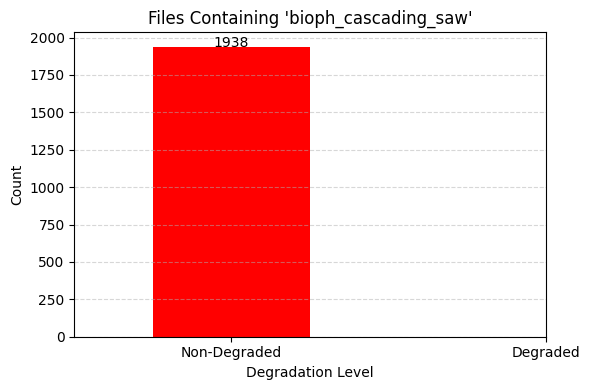

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV (you've done this already)
df = pd.read_csv(path)
df['sounds'] = df['sounds'].apply(eval)  # parse string to set

# Add a column to classify as degraded or non-degraded
df['degraded'] = df['filepath'].str.contains("Degraded", case=False)

# Add a column for bioph_cascading_saw presence
df['has_cascading_saw'] = df['sounds'].apply(lambda s: 'bioph_cascading_saw' in s)

# Filter only the rows that contain cascading_saw
casc_saw_df = df[df['has_cascading_saw']]

# Count how many of these are degraded vs not
count_table = casc_saw_df['degraded'].value_counts()

# Plot
plt.figure(figsize=(6, 4))
count_table.plot(kind='bar', color=['green' if not x else 'red' for x in count_table.index])
plt.xticks(ticks=[0,1], labels=['Non-Degraded', 'Degraded'], rotation=0)
plt.title("Files Containing 'bioph_cascading_saw'")
plt.ylabel("Count")
plt.xlabel("Degradation Level")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotate exact values
for i, v in enumerate(count_table.values):
    plt.text(i, v + 1, str(v), ha='center')

plt.show()
